In [6]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import os

os.makedirs('images', exist_ok=True)

df = pd.read_csv('data/creditcard.csv')
print(f"데이터 크기: {df.shape}")

데이터 크기: (284807, 31)


In [8]:
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

df = df.drop(['Amount', 'Time'], axis=1)
print("스케일링 완료!")
print(df.shape)

스케일링 완료!
(284807, 31)


In [9]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"학습 데이터: {X_train.shape}")
print(f"테스트 데이터: {X_test.shape}")
print(f"\n학습 데이터 사기 비율:\n{y_train.value_counts()}")

학습 데이터: (227845, 30)
테스트 데이터: (56962, 30)

학습 데이터 사기 비율:
Class
0    227451
1       394
Name: count, dtype: int64


In [10]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"SMOTE 적용 전: {y_train.value_counts().to_dict()}")
print(f"SMOTE 적용 후: {pd.Series(y_train_sm).value_counts().to_dict()}")

SMOTE 적용 전: {0: 227451, 1: 394}
SMOTE 적용 후: {0: 227451, 1: 227451}


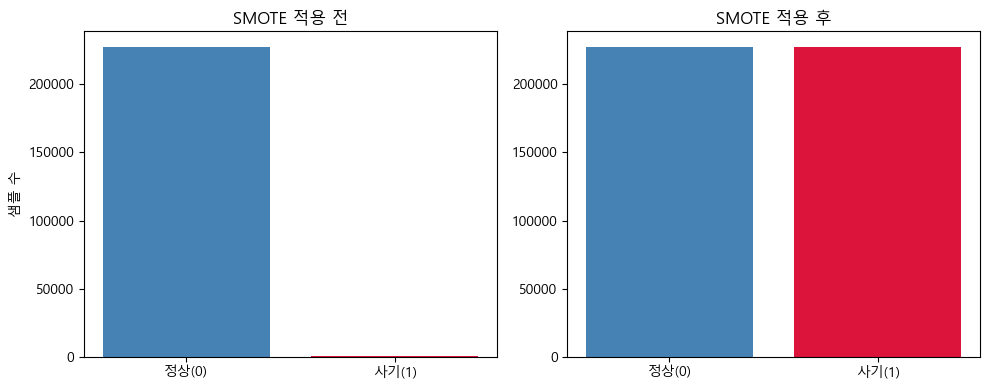

전처리 완료!


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['정상(0)', '사기(1)'],
            [sum(y_train==0), sum(y_train==1)],
            color=['steelblue', 'crimson'])
axes[0].set_title('SMOTE 적용 전')
axes[0].set_ylabel('샘플 수')

axes[1].bar(['정상(0)', '사기(1)'],
            [sum(y_train_sm==0), sum(y_train_sm==1)],
            color=['steelblue', 'crimson'])
axes[1].set_title('SMOTE 적용 후')

plt.tight_layout()
plt.savefig('images/smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("전처리 완료!")